# E-Commerce Sales & Customer Analytics

## Objective
Analyze e-commerce transaction data to identify sales trends,
customer behavior, product performance, regional performance,
and profitability patterns.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SQL
- Power BI

### Business Questions
1. How are sales and profit changing over time?
2. Which products and categories generate the most revenue?
3. Which customers contribute the most revenue?
4. Which regions perform best?
5. How does discounting affect profitability?
6. Which customer segments have the highest value?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import pandas as pd

url = "https://gist.githubusercontent.com/SharmaAshwini/8bd642f6c46792a9c40c8ccad60391e9/raw/4fd45d58a0a81c69814d270d7658f5e2a2d81154/Sample_Superstore.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9994, 21)


In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Orders:", df["Order ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())
print("Categories:", df["Category"].nunique())
print("Sub-Categories:", df["Sub-Category"].nunique())
print("Regions:", df["Region"].nunique())

Rows: 9994
Columns: 21
Unique Customers: 793
Unique Orders: 5009
Unique Products: 1862
Categories: 3
Sub-Categories: 17
Regions: 4


In [10]:
print("Total rows:", len(df))
print("Unique Orders:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())

Total rows: 9994
Unique Orders: 5009
Unique Customers: 793
Unique Products: 1862


In [11]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


/tmp/ipykernel_1256/991497833.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(df["Order Date"])
/tmp/ipykernel_1256/991497833.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"])


In [12]:
print("Order date range:", df["Order Date"].min(), "to", df["Order Date"].max())

Order date range: 2014-01-02 00:00:00 to 2017-12-30 00:00:00


In [13]:
print("Sales <= 0:", (df["Sales"] <= 0).sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Discount < 0:", (df["Discount"] < 0).sum())
print("Discount > 1:", (df["Discount"] > 1).sum())
print("Negative Profit:", (df["Profit"] < 0).sum())

Sales <= 0: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0
Negative Profit: 1871


In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [15]:
df["Year"] = df["Order Date"].dt.year
df["Quarter"] = "Q" + df["Order Date"].dt.quarter.astype(str)
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.strftime("%B")
df["Year_Month"] = df["Order Date"].dt.to_period("M").astype(str)

In [16]:
df["Shipping_Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [17]:
df["Profit_Margin"] = np.where(
    df["Sales"] != 0,
    df["Profit"] / df["Sales"],
    0
)

In [18]:
df[[
    "Order Date",
    "Year",
    "Quarter",
    "Month_Name",
    "Year_Month",
    "Shipping_Days",
    "Profit_Margin"
]].head()

,Order Date,Year,Quarter,Month_Name,Year_Month,Shipping_Days,Profit_Margin
0,2016-08-11,2016,Q3,August,2016-08,92,0.1600
1,2016-08-11,2016,Q3,August,2016-08,92,0.3000
2,2016-12-06,2016,Q4,December,2016-12,-173,0.4700
3,2015-11-10,2015,Q4,November,2015-11,-23,-0.4000
4,2015-11-10,2015,Q4,November,2015-11,-23,0.1125


In [19]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

overall_profit_margin = total_profit / total_sales

print(f"Total Sales        : ${total_sales:,.2f}")
print(f"Total Profit       : ${total_profit:,.2f}")
print(f"Total Quantity     : {total_quantity:,}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Overall Profit %   : {overall_profit_margin:.2%}")

Total Sales        : $2,297,200.86
Total Profit       : $286,397.02
Total Quantity     : 37,873
Total Orders       : 5,009
Total Customers    : 793
Overall Profit %   : 12.47%


In [20]:
monthly_analysis = (
    df.groupby("Year_Month")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

monthly_analysis.head()

,Year_Month,Sales,Profit,Orders
0,2014-01,28953.706,4549.4546,58
1,2014-02,12743.108,2654.5569,47
2,2014-03,54801.906,92.6990,80
3,2014-04,24710.016,4601.0714,60
4,2014-05,29639.834,3912.2499,77


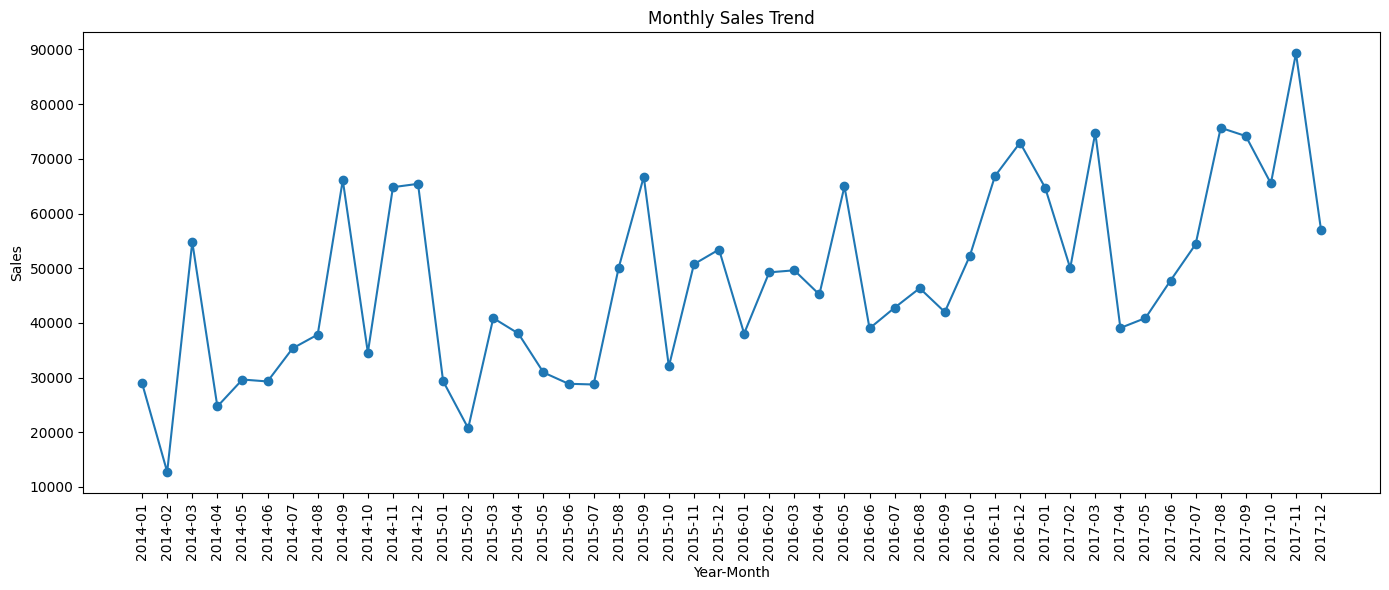

In [21]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

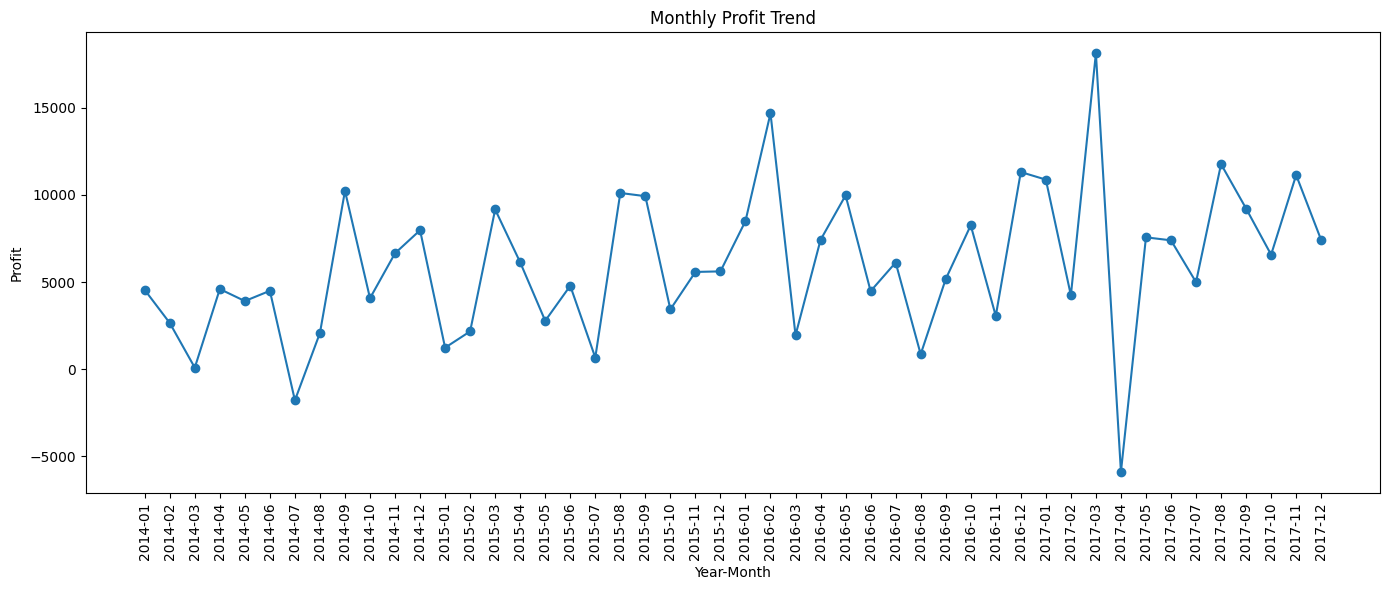

In [22]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["Year_Month"],
    monthly_analysis["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Year-Month")
plt.ylabel("Profit")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [23]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

category_analysis["Profit_Margin"] = (
    category_analysis["Profit"] /
    category_analysis["Sales"]
)

category_analysis.sort_values("Sales", ascending=False)

,Category,Sales,Profit,Quantity,Orders,Profit_Margin
2,Technology,836154.0330,145454.9481,6939,1544,0.173957
0,Furniture,741999.7953,18451.2728,8028,1764,0.024867
1,Office Supplies,719047.0320,122490.8008,22906,3742,0.170352


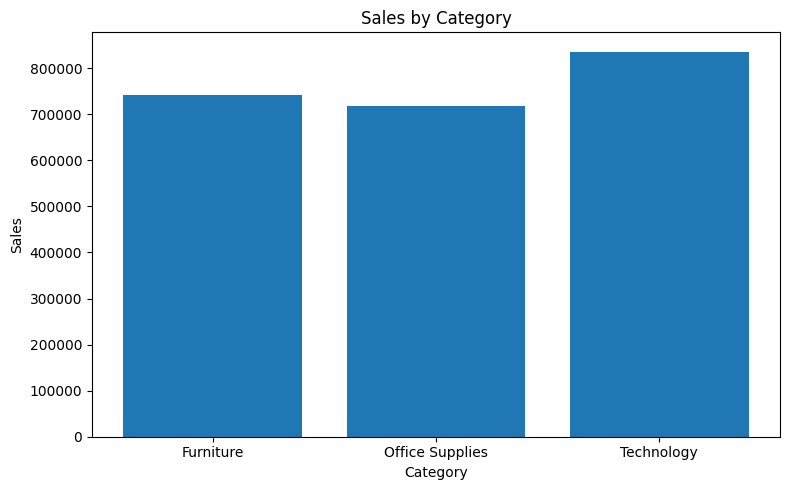

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

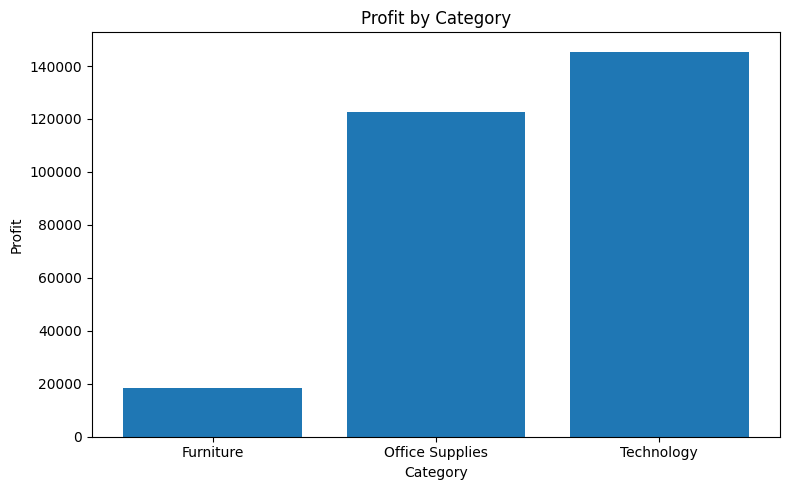

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis["Category"],
    category_analysis["Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [26]:
discount_analysis = (
    df.groupby("Discount")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Sales"]
)

discount_analysis

,Discount,Sales,Profit,Orders,Profit_Margin
0,0.00,1.087908e+06,320987.6032,2644,0.295050
1,0.10,5.436935e+04,9029.1770,89,0.166071
2,0.15,2.755852e+04,1418.9915,51,0.051490
3,0.20,7.645944e+05,90337.3060,2407,0.118151
4,0.30,1.032267e+05,-10369.2774,211,-0.100452
5,0.32,1.449346e+04,-2391.1377,27,-0.164980
6,0.40,1.164178e+05,-23057.0504,185,-0.198054
7,0.45,5.484974e+03,-2493.1111,10,-0.454535
8,0.50,5.891854e+04,-20506.4281,64,-0.348047
9,0.60,6.644700e+03,-5944.6552,127,-0.894646


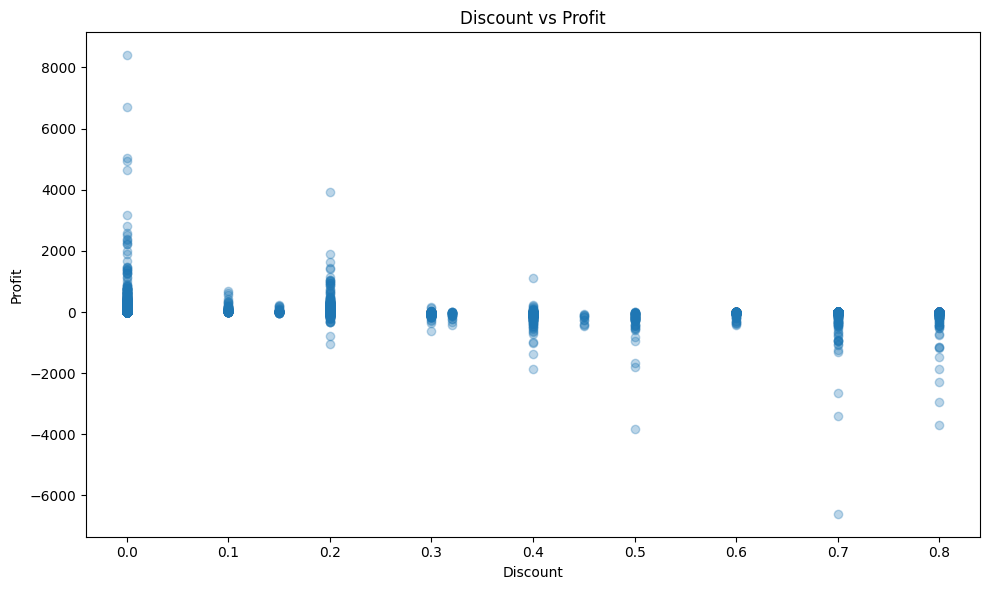

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.3
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [28]:
df.to_csv("ecommerce_cleaned.csv", index=False)

print("Saved:", df.shape)

Saved: (9994, 28)


In [29]:
customer_summary = (
    df.groupby(["Customer ID", "Customer Name", "Segment"])
      .agg(
          Orders=("Order ID", "nunique"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          First_Order=("Order Date", "min"),
          Last_Order=("Order Date", "max")
      )
      .reset_index()
)

customer_summary["Average_Order_Value"] = (
    customer_summary["Sales"] / customer_summary["Orders"]
)

customer_summary["Profit_Margin"] = (
    customer_summary["Profit"] / customer_summary["Sales"]
)

customer_summary.head()

,Customer ID,Customer Name,Segment,Orders,Sales,Profit,Quantity,First_Order,Last_Order,Average_Order_Value,Profit_Margin
0,AA-10315,Alex Avila,Consumer,5,5563.560,-362.8825,30,2014-03-31,2017-06-29,1112.712000,-0.065225
1,AA-10375,Allen Armold,Consumer,9,1056.390,277.3824,41,2014-04-21,2017-11-12,117.376667,0.262576
2,AA-10480,Andrew Allen,Consumer,4,1790.512,435.8274,36,2014-04-05,2017-04-15,447.628000,0.243409
3,AA-10645,Anna Andreadi,Consumer,6,5086.935,857.8033,64,2014-01-12,2017-05-11,847.822500,0.168629
4,AB-10015,Aaron Bergman,Consumer,3,886.156,129.3465,13,2014-02-18,2016-10-11,295.385333,0.145964


In [30]:
top_customers_sales = (
    customer_summary
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_customers_sales[
    [
        "Customer Name",
        "Segment",
        "Orders",
        "Sales",
        "Profit",
        "Average_Order_Value"
    ]
]

,Customer Name,Segment,Orders,Sales,Profit,Average_Order_Value
700,Sean Miller,Home Office,5,25043.050,-1980.7393,5008.610000
741,Tamara Chand,Corporate,5,19052.218,8981.3239,3810.443600
621,Raymond Buch,Consumer,6,15117.339,6976.0959,2519.556500
730,Tom Ashbrook,Home Office,4,14595.620,4703.7883,3648.905000
6,Adrian Barton,Consumer,10,14473.571,5444.8055,1447.357100
434,Ken Lonsdale,Consumer,12,14175.229,806.8550,1181.269083
669,Sanjit Chand,Consumer,9,14142.334,5757.4119,1571.370444
327,Hunter Lopez,Consumer,6,12873.298,5622.4292,2145.549667
683,Sanjit Engle,Consumer,11,12209.438,2650.6769,1109.948909
131,Christopher Conant,Consumer,5,12129.072,2177.0493,2425.814400


In [31]:
top_customers_profit = (
    customer_summary
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_customers_profit[
    [
        "Customer Name",
        "Segment",
        "Orders",
        "Sales",
        "Profit",
        "Profit_Margin"
    ]
]

,Customer Name,Segment,Orders,Sales,Profit,Profit_Margin
741,Tamara Chand,Corporate,5,19052.218,8981.3239,0.471406
621,Raymond Buch,Consumer,6,15117.339,6976.0959,0.461463
669,Sanjit Chand,Consumer,9,14142.334,5757.4119,0.407105
327,Hunter Lopez,Consumer,6,12873.298,5622.4292,0.436751
6,Adrian Barton,Consumer,10,14473.571,5444.8055,0.376190
730,Tom Ashbrook,Home Office,4,14595.620,4703.7883,0.322274
160,Christopher Martinez,Consumer,4,8954.020,3899.8904,0.435546
424,Keith Dawkins,Corporate,12,8181.256,3038.6254,0.371413
48,Andy Reiter,Consumer,6,6608.448,2884.6208,0.436505
234,Daniel Raglin,Home Office,8,8350.868,2869.0760,0.343566


In [32]:
segment_analysis = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

segment_analysis["Profit_Margin"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"]
)

segment_analysis["Average_Order_Value"] = (
    segment_analysis["Sales"] / segment_analysis["Orders"]
)

segment_analysis

,Segment,Sales,Profit,Orders,Customers,Quantity,Profit_Margin,Average_Order_Value
0,Consumer,1.161401e+06,134119.2092,2586,409,19521,0.115481,449.111116
1,Corporate,7.061464e+05,91979.1340,1514,236,11608,0.130255,466.411075
2,Home Office,4.296531e+05,60298.6785,909,148,6744,0.140343,472.665730


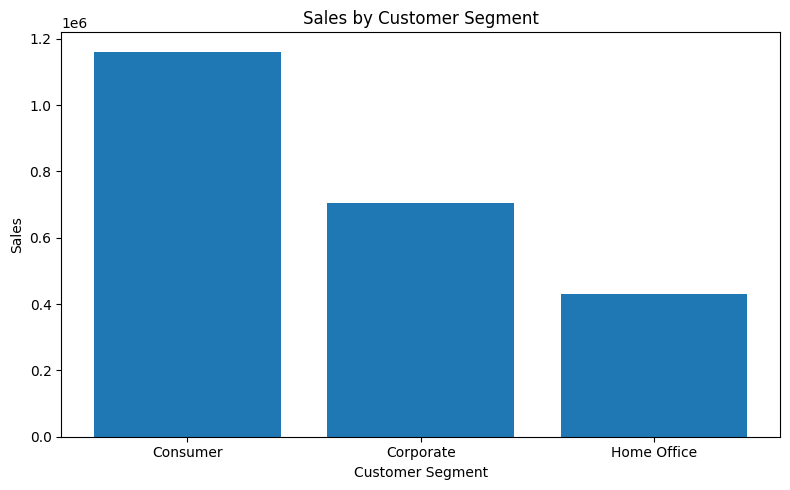

In [33]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis["Segment"],
    segment_analysis["Sales"]
)

plt.title("Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

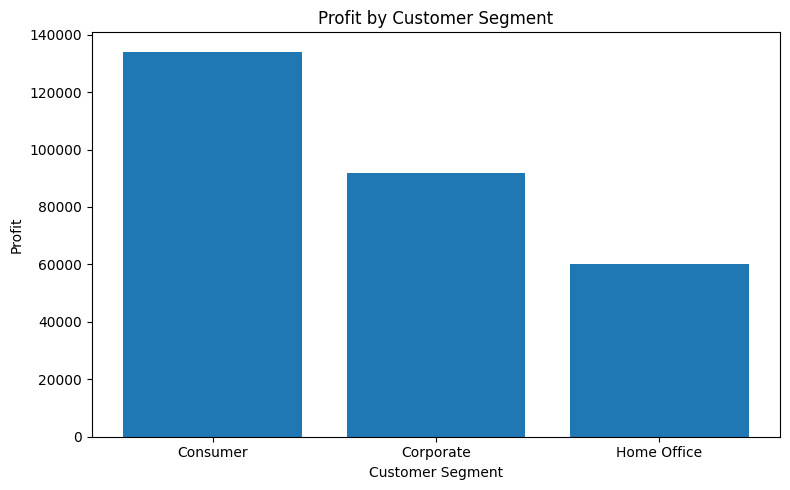

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_analysis["Segment"],
    segment_analysis["Profit"]
)

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [35]:
repeat_customer_stats = (
    customer_summary["Orders"]
    .value_counts()
    .sort_index()
)

repeat_customer_stats

,count
Orders,
1,12
2,34
3,53
4,96
5,134
6,107
7,116
8,82
9,71


In [36]:
customer_summary["Customer_Type"] = np.where(
    customer_summary["Orders"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_type_analysis = (
    customer_summary.groupby("Customer_Type")
    .agg(
        Customers=("Customer ID", "nunique"),
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

customer_type_analysis["Sales_Share"] = (
    customer_type_analysis["Sales"] /
    customer_type_analysis["Sales"].sum()
)

customer_type_analysis

,Customer_Type,Customers,Sales,Profit,Sales_Share
0,One-Time Customer,12,5.167640e+03,767.3746,0.00225
1,Repeat Customer,781,2.292033e+06,285629.6471,0.99775


In [37]:
customer_summary_sorted = customer_summary.sort_values(
    "Sales",
    ascending=False
).reset_index(drop=True)

customer_summary_sorted["Cumulative_Sales"] = (
    customer_summary_sorted["Sales"].cumsum()
)

customer_summary_sorted["Cumulative_Sales_Share"] = (
    customer_summary_sorted["Cumulative_Sales"] /
    customer_summary_sorted["Sales"].sum()
)

customer_summary_sorted.head(20)

,Customer ID,Customer Name,Segment,Orders,Sales,Profit,Quantity,First_Order,Last_Order,Average_Order_Value,Profit_Margin,Customer_Type,Cumulative_Sales,Cumulative_Sales_Share
0,SM-20320,Sean Miller,Home Office,5,25043.050,-1980.7393,50,2014-03-18,2017-12-10,5008.610000,-0.079093,Repeat Customer,25043.050,0.010902
1,TC-20980,Tamara Chand,Corporate,5,19052.218,8981.3239,42,2014-07-11,2016-11-26,3810.443600,0.471406,Repeat Customer,44095.268,0.019195
2,RB-19360,Raymond Buch,Consumer,6,15117.339,6976.0959,71,2016-01-04,2017-09-25,2519.556500,0.461463,Repeat Customer,59212.607,0.025776
3,TA-21385,Tom Ashbrook,Home Office,4,14595.620,4703.7883,36,2014-12-09,2017-10-22,3648.905000,0.322274,Repeat Customer,73808.227,0.032130
4,AB-10105,Adrian Barton,Consumer,10,14473.571,5444.8055,73,2014-12-20,2017-11-19,1447.357100,0.376190,Repeat Customer,88281.798,0.038430
5,KL-16645,Ken Lonsdale,Consumer,12,14175.229,806.8550,113,2014-07-25,2017-11-13,1181.269083,0.056920,Repeat Customer,102457.027,0.044601
6,SC-20095,Sanjit Chand,Consumer,9,14142.334,5757.4119,87,2014-02-09,2017-01-15,1571.370444,0.407105,Repeat Customer,116599.361,0.050757
7,HL-15040,Hunter Lopez,Consumer,6,12873.298,5622.4292,50,2014-01-20,2017-11-17,2145.549667,0.436751,Repeat Customer,129472.659,0.056361
8,SE-20110,Sanjit Engle,Consumer,11,12209.438,2650.6769,78,2014-09-22,2017-12-21,1109.948909,0.217101,Repeat Customer,141682.097,0.061676
9,CC-12370,Christopher Conant,Consumer,5,12129.072,2177.0493,34,2016-05-23,2017-11-17,2425.814400,0.179490,Repeat Customer,153811.169,0.066956


In [38]:
customer_summary.to_csv(
    "customer_summary.csv",
    index=False
)

In [39]:
product_summary = (
    df.groupby(["Product ID", "Product Name", "Category", "Sub-Category"])
      .agg(
          Orders=("Order ID", "nunique"),
          Quantity=("Quantity", "sum"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Avg_Discount=("Discount", "mean")
      )
      .reset_index()
)

product_summary["Profit_Margin"] = (
    product_summary["Profit"] / product_summary["Sales"]
)

product_summary.head()

,Product ID,Product Name,Category,Sub-Category,Orders,Quantity,Sales,Profit,Avg_Discount,Profit_Margin
0,FUR-BO-10000112,"Bush Birmingham Collection Bookcase, Dark Cherry",Furniture,Bookcases,1,9,825.174,-117.8820,0.300000,-0.142857
1,FUR-BO-10000330,"Sauder Camden County Barrister Bookcase, Plank...",Furniture,Bookcases,3,10,1064.624,24.1960,0.100000,0.022727
2,FUR-BO-10000362,Sauder Inglewood Library Bookcases,Furniture,Bookcases,5,14,2154.348,311.1836,0.130000,0.144444
3,FUR-BO-10000468,O'Sullivan 2-Shelf Heavy-Duty Bookcases,Furniture,Bookcases,6,21,723.842,-133.1092,0.183333,-0.183893
4,FUR-BO-10000711,"Hon Metal Bookcases, Gray",Furniture,Bookcases,2,12,851.760,229.9752,0.000000,0.270000


In [40]:
top_products_sales = (
    product_summary
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_products_sales[
    [
        "Product Name",
        "Category",
        "Sub-Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Avg_Discount"
    ]
]

,Product Name,Category,Sub-Category,Sales,Profit,Profit_Margin,Avg_Discount
1640,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,4.090909e-01,0.120000
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7.753039e+03,2.824074e-01,0.240000
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1.811078e+03,-8.000000e-02,0.500000
82,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,5.684342e-14,2.599082e-18,0.200000
701,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,1.126697e-01,0.300000
667,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.500,7.609800e+02,4.000000e-02,0.522222
1630,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6.983884e+03,3.707006e-01,0.200000
1657,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4.094977e+03,2.228571e-01,0.166667
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1.878166e+03,-1.045455e-01,0.450000
1443,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.312,-2.620048e+02,-1.538462e-02,0.066667


In [41]:
top_products_profit = (
    product_summary
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_products_profit[
    [
        "Product Name",
        "Category",
        "Sub-Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Avg_Discount"
    ]
]

,Product Name,Category,Sub-Category,Sales,Profit,Profit_Margin,Avg_Discount
1640,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,25199.9280,0.409091,0.120000
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7753.0390,0.282407,0.240000
1630,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6983.8836,0.370701,0.200000
1637,Canon PC1060 Personal Laser Copier,Technology,Copiers,11619.834,4570.9347,0.393373,0.150000
1657,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4094.9766,0.222857,0.166667
1693,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,7699.890,3772.9461,0.490000,0.000000
1656,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,14299.890,3717.9714,0.260000,0.000000
1541,Plantronics Savi W720 Multi-Device Wireless He...,Technology,Accessories,9367.290,3696.2820,0.394595,0.057143
692,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,15875.916,3345.2823,0.210714,0.333333
1643,Zebra ZM400 Thermal Label Printer,Technology,Machines,6965.700,3343.5360,0.480000,0.000000


In [42]:
loss_products = (
    product_summary[product_summary["Profit"] < 0]
    .sort_values("Profit")
)

print("Loss-making products:", len(loss_products))

Loss-making products: 306


In [43]:
loss_products.head(10)[
    [
        "Product Name",
        "Category",
        "Sub-Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Avg_Discount"
    ]
]

,Product Name,Category,Sub-Category,Sales,Profit,Profit_Margin,Avg_Discount
1645,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.963,-8879.9704,-0.800000,0.533333
1650,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.901,-4589.9730,-0.272727,0.400000
1696,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,-3839.9904,-0.480000,0.500000
326,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.640,-2876.1156,-0.290000,0.280000
344,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.725,-1934.3976,-0.202667,0.350000
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1878.1662,-0.104545,0.450000
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1811.0784,-0.080000,0.500000
1465,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.200,-1299.1836,-0.078000,0.100000
346,Balt Solid Wood Round Tables,Furniture,Tables,6518.754,-1201.0581,-0.184247,0.200000
375,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.250,-1148.4375,-0.673077,0.483333


In [44]:
subcategory_analysis = (
    df.groupby(["Category", "Sub-Category"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Quantity=("Quantity", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

subcategory_analysis["Profit_Margin"] = (
    subcategory_analysis["Profit"] /
    subcategory_analysis["Sales"]
)

subcategory_analysis.sort_values("Profit", ascending=False)

,Category,Sub-Category,Sales,Profit,Quantity,Orders,Profit_Margin
14,Technology,Copiers,149528.0300,55617.8249,234,68,0.371956
16,Technology,Phones,330007.0540,44515.7306,3289,814,0.134893
13,Technology,Accessories,167380.3180,41936.6357,2976,718,0.250547
10,Office Supplies,Paper,78479.2060,34053.5693,5178,1191,0.433918
6,Office Supplies,Binders,203412.7330,30221.7633,5974,1316,0.148574
1,Furniture,Chairs,328449.1030,26590.1663,2356,576,0.080957
11,Office Supplies,Storage,223843.6080,21278.8264,3158,777,0.095061
4,Office Supplies,Appliances,107532.1610,18138.0054,1729,451,0.168675
2,Furniture,Furnishings,91705.1640,13059.1436,3563,877,0.142404
7,Office Supplies,Envelopes,16476.4020,6964.1767,906,249,0.422676


In [45]:
subcategory_analysis.sort_values("Profit").head(10)

,Category,Sub-Category,Sales,Profit,Quantity,Orders,Profit_Margin
3,Furniture,Tables,206965.5320,-17725.4811,1241,307,-0.085645
0,Furniture,Bookcases,114879.9963,-3472.5560,868,224,-0.030228
12,Office Supplies,Supplies,46673.5380,-1189.0995,647,187,-0.025477
8,Office Supplies,Fasteners,3024.2800,949.5182,914,215,0.313965
15,Technology,Machines,189238.6310,3384.7569,440,112,0.017886
9,Office Supplies,Labels,12486.3120,5546.2540,1400,346,0.444187
5,Office Supplies,Art,27118.7920,6527.7870,3000,731,0.240711
7,Office Supplies,Envelopes,16476.4020,6964.1767,906,249,0.422676
2,Furniture,Furnishings,91705.1640,13059.1436,3563,877,0.142404
4,Office Supplies,Appliances,107532.1610,18138.0054,1729,451,0.168675


In [46]:
subcategory_analysis.sort_values("Profit", ascending=False).head(10)

,Category,Sub-Category,Sales,Profit,Quantity,Orders,Profit_Margin
14,Technology,Copiers,149528.030,55617.8249,234,68,0.371956
16,Technology,Phones,330007.054,44515.7306,3289,814,0.134893
13,Technology,Accessories,167380.318,41936.6357,2976,718,0.250547
10,Office Supplies,Paper,78479.206,34053.5693,5178,1191,0.433918
6,Office Supplies,Binders,203412.733,30221.7633,5974,1316,0.148574
1,Furniture,Chairs,328449.103,26590.1663,2356,576,0.080957
11,Office Supplies,Storage,223843.608,21278.8264,3158,777,0.095061
4,Office Supplies,Appliances,107532.161,18138.0054,1729,451,0.168675
2,Furniture,Furnishings,91705.164,13059.1436,3563,877,0.142404
7,Office Supplies,Envelopes,16476.402,6964.1767,906,249,0.422676


In [47]:
sales_profit_analysis = product_summary.copy()

sales_threshold = sales_profit_analysis["Sales"].quantile(0.75)

high_sales_low_profit = sales_profit_analysis[
    (sales_profit_analysis["Sales"] >= sales_threshold) &
    (sales_profit_analysis["Profit"] < 0)
].sort_values("Sales", ascending=False)

high_sales_low_profit[
    [
        "Product Name",
        "Category",
        "Sub-Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Avg_Discount"
    ]
].head(15)

,Product Name,Category,Sub-Category,Sales,Profit,Profit_Margin,Avg_Discount
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.4800,-1811.0784,-0.080000,0.500000
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.0680,-1878.1662,-0.104545,0.450000
1443,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.3120,-262.0048,-0.015385,0.066667
1650,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.9010,-4589.9730,-0.272727,0.400000
1465,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.2000,-1299.1836,-0.078000,0.100000
49,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,15610.9656,-669.5448,-0.042889,0.234000
363,Bretford Rectangular Conference Table Tops,Furniture,Tables,12995.2915,-327.2331,-0.025181,0.245833
1645,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.9630,-8879.9704,-0.800000,0.533333
326,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.6400,-2876.1156,-0.290000,0.280000
344,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.7250,-1934.3976,-0.202667,0.350000


In [48]:
product_summary.to_csv(
    "product_summary.csv",
    index=False
)

subcategory_analysis.to_csv(
    "subcategory_analysis.csv",
    index=False
)

In [49]:
top_products_sales = (
    product_summary
    .sort_values("Sales", ascending=False)
    .head(10)
)

top_products_sales[
    [
        "Product Name",
        "Category",
        "Sub-Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Avg_Discount"
    ]
]

,Product Name,Category,Sub-Category,Sales,Profit,Profit_Margin,Avg_Discount
1640,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,4.090909e-01,0.120000
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7.753039e+03,2.824074e-01,0.240000
1669,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1.811078e+03,-8.000000e-02,0.500000
82,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,5.684342e-14,2.599082e-18,0.200000
701,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,1.126697e-01,0.300000
667,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.500,7.609800e+02,4.000000e-02,0.522222
1630,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6.983884e+03,3.707006e-01,0.200000
1657,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4.094977e+03,2.228571e-01,0.166667
858,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1.878166e+03,-1.045455e-01,0.450000
1443,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.312,-2.620048e+02,-1.538462e-02,0.066667


In [50]:
top_products_profit = (
    product_summary
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_products_profit[
    [
        "Product Name",
        "Category",
        "Sub-Category",
        "Sales",
        "Profit",
        "Profit_Margin",
        "Avg_Discount"
    ]
]

,Product Name,Category,Sub-Category,Sales,Profit,Profit_Margin,Avg_Discount
1640,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,25199.9280,0.409091,0.120000
787,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7753.0390,0.282407,0.240000
1630,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6983.8836,0.370701,0.200000
1637,Canon PC1060 Personal Laser Copier,Technology,Copiers,11619.834,4570.9347,0.393373,0.150000
1657,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4094.9766,0.222857,0.166667
1693,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,7699.890,3772.9461,0.490000,0.000000
1656,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,14299.890,3717.9714,0.260000,0.000000
1541,Plantronics Savi W720 Multi-Device Wireless He...,Technology,Accessories,9367.290,3696.2820,0.394595,0.057143
692,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,15875.916,3345.2823,0.210714,0.333333
1643,Zebra ZM400 Thermal Label Printer,Technology,Machines,6965.700,3343.5360,0.480000,0.000000


In [51]:
region_analysis = (
    df.groupby("Region")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Customers=("Customer ID", "nunique"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

region_analysis["Profit_Margin"] = (
    region_analysis["Profit"] / region_analysis["Sales"]
)

region_analysis["Average_Order_Value"] = (
    region_analysis["Sales"] / region_analysis["Orders"]
)

region_analysis

,Region,Sales,Profit,Orders,Customers,Quantity,Profit_Margin,Average_Order_Value
0,Central,501239.8908,39706.3625,1175,629,8780,0.079216,426.587141
1,East,678781.2400,91522.7800,1401,674,10618,0.134834,484.497673
2,South,391721.9050,46749.4303,822,512,6209,0.119343,476.547330
3,West,725457.8245,108418.4489,1611,686,12266,0.149448,450.315223


In [52]:
state_analysis = (
    df.groupby(["State", "Region"])
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

state_analysis["Profit_Margin"] = (
    state_analysis["Profit"] / state_analysis["Sales"]
)

state_analysis.sort_values("Profit").head(10)

,State,Region,Sales,Profit,Orders,Profit_Margin
41,Texas,Central,170188.0458,-25729.3563,487,-0.151182
33,Ohio,East,78258.1360,-16971.3766,236,-0.216864
36,Pennsylvania,East,116511.9140,-15559.9603,288,-0.133548
11,Illinois,Central,80166.1010,-12607.8870,276,-0.157272
31,North Carolina,South,55603.1640,-7490.9122,136,-0.134721
4,Colorado,West,32108.1180,-6527.8579,79,-0.203309
40,Tennessee,South,30661.8730,-5341.6936,91,-0.174213
1,Arizona,West,35282.0010,-3427.9246,108,-0.097158
8,Florida,South,89473.7080,-3399.3017,200,-0.037992
35,Oregon,West,17431.1500,-1190.4705,56,-0.068296


In [53]:
state_analysis.sort_values("Profit", ascending=False).head(10)

,State,Region,Sales,Profit,Orders,Profit_Margin
3,California,West,457687.6315,76381.3871,1021,0.166885
30,New York,East,310876.2710,74038.5486,562,0.238161
45,Washington,West,138641.2700,33402.6517,256,0.240929
20,Michigan,Central,76269.6140,24463.1876,117,0.320746
44,Virginia,South,70636.7200,18597.9504,115,0.263290
12,Indiana,Central,53555.3600,18382.9363,73,0.343251
9,Georgia,South,49095.8400,16250.0433,91,0.330986
15,Kentucky,South,36591.7500,11199.6966,61,0.306072
21,Minnesota,Central,29863.1500,10823.1874,44,0.362426
6,Delaware,East,27451.0690,9977.3748,44,0.363460


In [54]:
df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0.10, 0.20, 0.30, 0.40, 0.50, 1.00],
    labels=[
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50%+"
    ]
)

In [55]:
discount_band_analysis = (
    df.groupby("Discount_Band", observed=True)
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique")
      )
      .reset_index()
)

discount_band_analysis["Profit_Margin"] = (
    discount_band_analysis["Profit"] /
    discount_band_analysis["Sales"]
)

discount_band_analysis

,Discount_Band,Sales,Profit,Orders,Profit_Margin
0,0-10%,1.142278e+06,330016.7802,2679,0.288911
1,10-20%,7.921529e+05,91756.2975,2436,0.115832
2,20-30%,1.032267e+05,-10369.2774,211,-0.100452
3,30-40%,1.309112e+05,-25448.1881,211,-0.194393
4,40-50%,6.440351e+04,-22999.5392,74,-0.357116
5,50%+,6.422874e+04,-76559.0513,685,-1.191975


In [56]:
discount_profit_corr = df["Discount"].corr(df["Profit"])

print(f"Correlation between Discount and Profit: {discount_profit_corr:.4f}")

Correlation between Discount and Profit: -0.2195


In [57]:
discount_detail = (
    df.groupby("Discount")
      .agg(
          Avg_Profit=("Profit", "mean"),
          Total_Profit=("Profit", "sum"),
          Sales=("Sales", "sum"),
          Transactions=("Profit", "size")
      )
      .reset_index()
)

discount_detail

,Discount,Avg_Profit,Total_Profit,Sales,Transactions
0,0.00,66.900292,320987.6032,1.087908e+06,4798
1,0.10,96.055074,9029.1770,5.436935e+04,94
2,0.15,27.288298,1418.9915,2.755852e+04,52
3,0.20,24.702572,90337.3060,7.645944e+05,3657
4,0.30,-45.679636,-10369.2774,1.032267e+05,227
5,0.32,-88.560656,-2391.1377,1.449346e+04,27
6,0.40,-111.927429,-23057.0504,1.164178e+05,206
7,0.45,-226.646464,-2493.1111,5.484974e+03,11
8,0.50,-310.703456,-20506.4281,5.891854e+04,66
9,0.60,-43.077212,-5944.6552,6.644700e+03,138


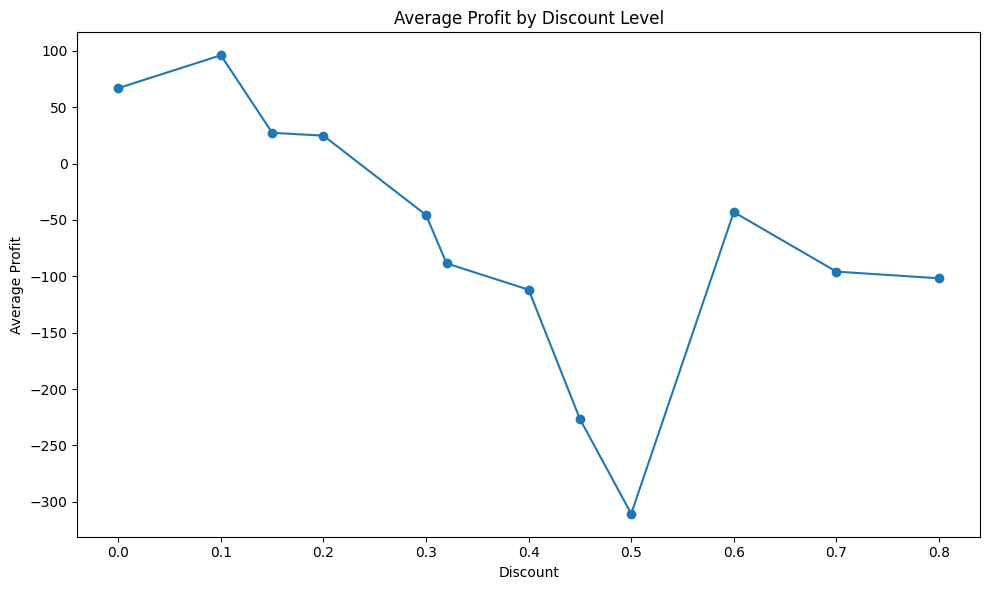

In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_detail["Discount"],
    discount_detail["Avg_Profit"],
    marker="o"
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")

plt.tight_layout()
plt.show()

In [59]:
shipping_analysis = (
    df.groupby("Ship Mode")
      .agg(
          Orders=("Order ID", "nunique"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Avg_Shipping_Days=("Shipping_Days", "mean")
      )
      .reset_index()
)

shipping_analysis

,Ship Mode,Orders,Sales,Profit,Avg_Shipping_Days
0,First Class,787,3.514284e+05,48969.8399,6.718466
1,Same Day,264,1.283631e+05,15891.7589,0.559853
2,Second Class,964,4.591936e+05,57446.6354,5.188175
3,Standard Class,2994,1.358216e+06,164088.7875,12.180295


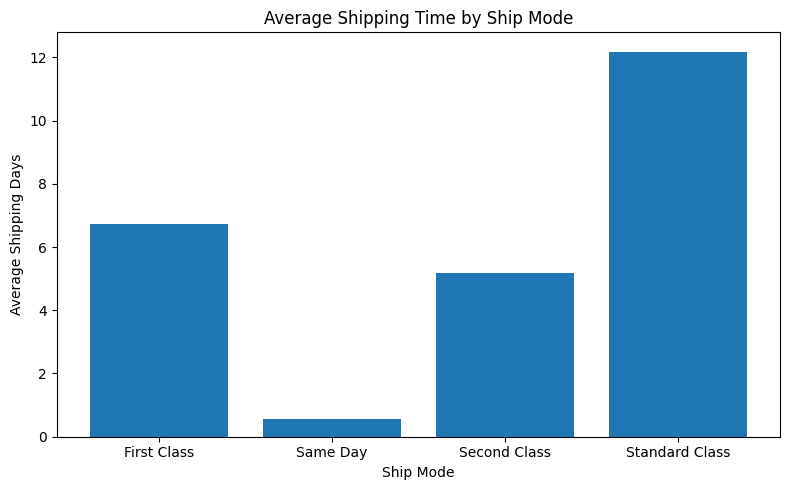

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    shipping_analysis["Ship Mode"],
    shipping_analysis["Avg_Shipping_Days"]
)

plt.title("Average Shipping Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.tight_layout()
plt.show()

In [61]:
region_shipping = (
    df.groupby("Region")
      .agg(
          Orders=("Order ID", "nunique"),
          Avg_Shipping_Days=("Shipping_Days", "mean"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

region_shipping

,Region,Orders,Avg_Shipping_Days,Sales,Profit
0,Central,1175,14.728368,501239.8908,39706.3625
1,East,1401,9.186447,678781.2400,91522.7800
2,South,822,7.090741,391721.9050,46749.4303
3,West,1611,6.729941,725457.8245,108418.4489


In [62]:
df.to_csv("ecommerce_cleaned.csv", index=False)

print("Final dataset shape:", df.shape)

Final dataset shape: (9994, 29)


In [63]:
customer_summary.to_csv("customer_summary.csv", index=False)
product_summary.to_csv("product_summary.csv", index=False)
subcategory_analysis.to_csv("subcategory_analysis.csv", index=False)
region_analysis.to_csv("region_analysis.csv", index=False)
discount_band_analysis.to_csv("discount_band_analysis.csv", index=False)
shipping_analysis.to_csv("shipping_analysis.csv", index=False)

In [64]:
discount_margin_corr = df["Discount"].corr(df["Profit_Margin"])

print(f"Discount vs Profit correlation: {df['Discount'].corr(df['Profit']):.4f}")
print(f"Discount vs Profit Margin correlation: {discount_margin_corr:.4f}")

Discount vs Profit correlation: -0.2195
Discount vs Profit Margin correlation: -0.8645


In [65]:
discount_summary = (
    df.groupby("Discount")
      .agg(
          Transactions=("Profit", "size"),
          Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Avg_Profit=("Profit", "mean"),
          Avg_Profit_Margin=("Profit_Margin", "mean")
      )
      .reset_index()
)

discount_summary

,Discount,Transactions,Sales,Total_Profit,Avg_Profit,Avg_Profit_Margin
0,0.00,4798,1.087908e+06,320987.6032,66.900292,0.340160
1,0.10,94,5.436935e+04,9029.1770,96.055074,0.155792
2,0.15,52,2.755852e+04,1418.9915,27.288298,0.034163
3,0.20,3657,7.645944e+05,90337.3060,24.702572,0.176839
4,0.30,227,1.032267e+05,-10369.2774,-45.679636,-0.115481
5,0.32,27,1.449346e+04,-2391.1377,-88.560656,-0.174292
6,0.40,206,1.164178e+05,-23057.0504,-111.927429,-0.222492
7,0.45,11,5.484974e+03,-2493.1111,-226.646464,-0.454545
8,0.50,66,5.891854e+04,-20506.4281,-310.703456,-0.549091
9,0.60,138,6.644700e+03,-5944.6552,-43.077212,-0.689130


In [66]:
import sqlite3

conn = sqlite3.connect("ecommerce_analytics.db")

df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("SQLite database created successfully.")

SQLite database created successfully.


In [67]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

sql_result = pd.read_sql_query(query, conn)

sql_result

,Category,Total_Sales,Total_Profit,Profit_Margin
0,Technology,836154.0330,145454.9481,0.173957
1,Furniture,741999.7953,18451.2728,0.024867
2,Office Supplies,719047.0320,122490.8008,0.170352


In [68]:
sql_script = """

-- ============================================================
-- E-Commerce Sales & Customer Analytics
-- SQL Business Analysis
-- ============================================================


-- 1. Overall Business KPIs
SELECT
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity,
    COUNT(DISTINCT "Order ID") AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales;


-- 2. Category Performance
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;


-- 3. Sub-Category Performance
SELECT
    Category,
    "Sub-Category",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY Category, "Sub-Category"
ORDER BY Total_Profit DESC;


-- 4. Monthly Sales and Profit
SELECT
    "Year_Month",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Orders
FROM sales
GROUP BY "Year_Month"
ORDER BY "Year_Month";


-- 5. Top 10 Customers by Sales
SELECT
    "Customer ID",
    "Customer Name",
    Segment,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY
    "Customer ID",
    "Customer Name",
    Segment
ORDER BY Total_Sales DESC
LIMIT 10;


-- 6. Top 10 Customers by Profit
SELECT
    "Customer ID",
    "Customer Name",
    Segment,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY
    "Customer ID",
    "Customer Name",
    Segment
ORDER BY Total_Profit DESC
LIMIT 10;


-- 7. Top 10 Products by Sales
SELECT
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category"
ORDER BY Total_Sales DESC
LIMIT 10;


-- 8. Loss-Making Products
SELECT
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category",
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category"
HAVING Total_Profit < 0
ORDER BY Total_Profit ASC
LIMIT 10;


-- 9. Regional Performance
SELECT
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin,
    COUNT(DISTINCT "Order ID") AS Orders,
    COUNT(DISTINCT "Customer ID") AS Customers
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;


-- 10. State Performance
SELECT
    State,
    Region,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY State, Region
ORDER BY Total_Profit ASC;


-- 11. Discount Impact
SELECT
    Discount,
    COUNT(*) AS Transactions,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    AVG(Profit) AS Avg_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY Discount
ORDER BY Discount;


-- 12. Shipping Performance
SELECT
    "Ship Mode",
    COUNT(DISTINCT "Order ID") AS Orders,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    AVG(Shipping_Days) AS Avg_Shipping_Days
FROM sales
GROUP BY "Ship Mode"
ORDER BY Avg_Shipping_Days;


-- 13. Region + Shipping Performance
SELECT
    Region,
    COUNT(DISTINCT "Order ID") AS Orders,
    AVG(Shipping_Days) AS Avg_Shipping_Days,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit
FROM sales
GROUP BY Region
ORDER BY Avg_Shipping_Days DESC;

"""

with open("business_analysis.sql", "w", encoding="utf-8") as f:
    f.write(sql_script)

print("business_analysis.sql created successfully!")

business_analysis.sql created successfully!


In [69]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    SUM(Profit) / SUM(Sales) AS Profit_Margin
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC;
"""

result = pd.read_sql_query(query, conn)

result

,Category,Total_Sales,Total_Profit,Profit_Margin
0,Technology,836154.0330,145454.9481,0.173957
1,Furniture,741999.7953,18451.2728,0.024867
2,Office Supplies,719047.0320,122490.8008,0.170352


In [70]:
monthly_analysis.to_csv("monthly_analysis.csv", index=False)
customer_summary.to_csv("customer_summary.csv", index=False)
product_summary.to_csv("product_summary.csv", index=False)
subcategory_analysis.to_csv("subcategory_analysis.csv", index=False)
region_analysis.to_csv("region_analysis.csv", index=False)
discount_summary.to_csv("discount_summary.csv", index=False)
shipping_analysis.to_csv("shipping_analysis.csv", index=False)

print("All analytical files saved.")

All analytical files saved.


In [71]:
df.to_csv("ecommerce_cleaned.csv", index=False)

In [72]:
requirements = """pandas
numpy
matplotlib
seaborn
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created.")

requirements.txt created.


In [73]:
import os

files = [
    "ecommerce_cleaned.csv",
    "customer_summary.csv",
    "product_summary.csv",
    "subcategory_analysis.csv",
    "region_analysis.csv",
    "discount_summary.csv",
    "shipping_analysis.csv",
    "business_analysis.sql",
    "requirements.txt",
    "ecommerce_analytics.db"
]

for file in files:
    print(f"{file}: {'✓' if os.path.exists(file) else '✗'}")

ecommerce_cleaned.csv: ✓
customer_summary.csv: ✓
product_summary.csv: ✓
subcategory_analysis.csv: ✓
region_analysis.csv: ✓
discount_summary.csv: ✓
shipping_analysis.csv: ✓
business_analysis.sql: ✓
requirements.txt: ✓
ecommerce_analytics.db: ✓


In [74]:
from google.colab import files

files.download("ecommerce_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
from google.colab import files

project_files = [
    "ecommerce_cleaned.csv",
    "customer_summary.csv",
    "product_summary.csv",
    "subcategory_analysis.csv",
    "region_analysis.csv",
    "discount_summary.csv",
    "shipping_analysis.csv",
    "business_analysis.sql",
    "requirements.txt"
]

for file in project_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>